In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

In [7]:
df = pd.read_csv(r"D:\E Drive\Sentiflow-Network Intrusion Detection\Data\Network_anomaly_data.csv")
df

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


In [8]:
print("shape",df.shape)
print(df.describe())
print(df.describe().T)
print(df.describe(include='object').T)

shape (125973, 43)
           duration      srcbytes      dstbytes           land  wrongfragment  \
count  125973.00000  1.259730e+05  1.259730e+05  125973.000000  125973.000000   
mean      287.14465  4.556674e+04  1.977911e+04       0.000198       0.022687   
std      2604.51531  5.870331e+06  4.021269e+06       0.014086       0.253530   
min         0.00000  0.000000e+00  0.000000e+00       0.000000       0.000000   
25%         0.00000  0.000000e+00  0.000000e+00       0.000000       0.000000   
50%         0.00000  4.400000e+01  0.000000e+00       0.000000       0.000000   
75%         0.00000  2.760000e+02  5.160000e+02       0.000000       0.000000   
max     42908.00000  1.379964e+09  1.309937e+09       1.000000       3.000000   

              urgent            hot  numfailedlogins       loggedin  \
count  125973.000000  125973.000000    125973.000000  125973.000000   
mean        0.000111       0.204409         0.001222       0.395736   
std         0.014366       2.149968   

In [ ]:
.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 39 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   duration                125973 non-null  int64  
 1   srcbytes                125973 non-null  int64  
 2   dstbytes                125973 non-null  int64  
 3   land                    125973 non-null  int64  
 4   wrongfragment           125973 non-null  int64  
 5   urgent                  125973 non-null  int64  
 6   hot                     125973 non-null  int64  
 7   numfailedlogins         125973 non-null  int64  
 8   loggedin                125973 non-null  int64  
 9   numcompromised          125973 non-null  int64  
 10  rootshell               125973 non-null  int64  
 11  suattempted             125973 non-null  int64  
 12  numroot                 125973 non-null  int64  
 13  numfilecreations        125973 non-null  int64  
 14  numshells           

In [20]:
df.select_dtypes(include=["object"]).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   protocoltype  125973 non-null  object
 1   service       125973 non-null  object
 2   flag          125973 non-null  object
 3   attack        125973 non-null  object
dtypes: object(4)
memory usage: 3.8+ MB


In [9]:
print(df.describe(include='object').T)

               count unique     top    freq
protocoltype  125973      3     tcp  102689
service       125973     70    http   40338
flag          125973     11      SF   74945
attack        125973     23  normal   67343


In [10]:
print("shape",df.shape)

shape (125973, 43)


In [11]:
# missing Values
missing = df.isnull().sum()

missing = missing[missing>0]

missing.sort_values(ascending=False)

Series([], dtype: int64)

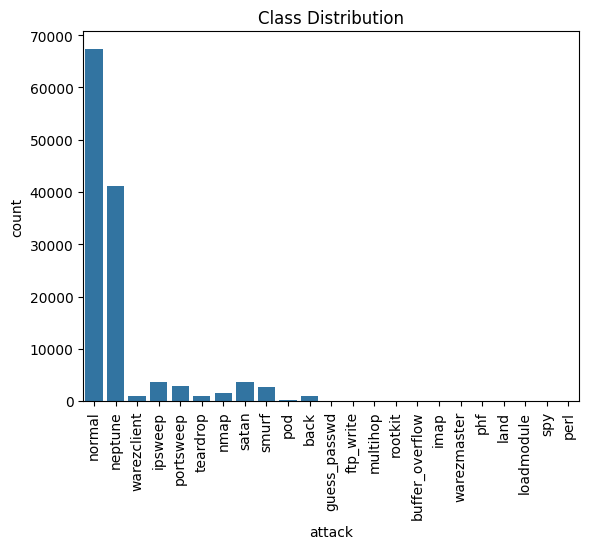

In [17]:
sns.countplot(x=df['attack'])
plt.title("Class Distribution")
plt.xticks(rotation=90)
plt.show()

In [ ]:
EXPECTED_FEATURES = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_hot_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
CATEGORICAL_FEATURES = ["protocol_type", "service", "flag"]
TARGET_CANDIDATES = ["attack", "label", "class", "target", "outcome", "attack_type"]
METADATA_CANDIDATES = ["difficulty", "difficulty_level", "last_flag", "index"]

RATE_FEATURES = [
    "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
    "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
]

NON_NEGATIVE_FEATURES = [
    "duration", "src_bytes", "dst_bytes", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "num_compromised", "num_root",
    "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "count", "srv_count", "dst_host_count",
    "dst_host_srv_count",
]

BINARY_CANDIDATES = [
    "land", "logged_in", "root_shell", "is_hot_login", "is_host_login",
    "is_guest_login",
]


def snake_case(value: object) -> str:
    text = str(value).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


def read_network_dataset(
    path: str | Path,
    sep: str = ",",
    has_header: bool | str = "auto",
) -> pd.DataFrame:
    """Load a KDD/NSL-KDD-like CSV with or without a header row."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found: {path}. Update DATA_FILE in the setup cell."
        )

    if has_header == "auto":
        preview = pd.read_csv(path, sep=sep, header=None, nrows=2, low_memory=False)
        first_row = {snake_case(v) for v in preview.iloc[0].tolist()}
        known_names = set(EXPECTED_FEATURES + TARGET_CANDIDATES + METADATA_CANDIDATES)
        header_hits = len(first_row.intersection(known_names))
        has_header = header_hits >= 5

    frame = pd.read_csv(
        path,
        sep=sep,
        header=0 if has_header else None,
        low_memory=False,
    )

    if not has_header:
        n_columns = frame.shape[1]
        if n_columns == len(EXPECTED_FEATURES):
            frame.columns = EXPECTED_FEATURES
        elif n_columns == len(EXPECTED_FEATURES) + 1:
            frame.columns = EXPECTED_FEATURES + ["attack"]
        elif n_columns == len(EXPECTED_FEATURES) + 2:
            frame.columns = EXPECTED_FEATURES + ["attack", "difficulty"]
        else:
            raise ValueError(
                f"Unexpected column count: {n_columns}. Expected 41, 42, or 43 columns. "
                "Inspect the file and assign column names explicitly."
            )

    frame.columns = [snake_case(c) for c in frame.columns]
    return frame


def infer_target_column(frame: pd.DataFrame) -> str:
    matches = [c for c in TARGET_CANDIDATES if c in frame.columns]
    if len(matches) == 1:
        return matches[0]
    if not matches:
        raise KeyError(
            "No target column was found. Set TARGET_COL manually after inspecting df.columns."
        )
    raise KeyError(f"Multiple possible target columns found: {matches}. Set TARGET_COL manually.")


def to_binary_anomaly(value: object) -> int | float:
    """Map normal/benign labels to 0 and all attack labels to 1."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (bool, np.bool_)):
        return int(value)
    if isinstance(value, (int, float, np.integer, np.floating)) and value in (0, 1):
        return int(value)

    cleaned = str(value).strip().lower().rstrip(".")
    normal_values = {"normal", "benign", "0", "false", "non_attack", "nonattack"}
    return 0 if cleaned in normal_values else 1


def save_figure(name: str) -> None:
    plt.tight_layout()
    plt.savefig(REPORT_FIGURE_DIR / f"{name}.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()


def save_table(table: pd.DataFrame, name: str) -> None:
    table.to_csv(REPORT_TABLE_DIR / f"{name}.csv", index=True)


# Load the source data.
df = read_network_dataset(DATA_FILE)
TARGET_COL = infer_target_column(df)

# Preserve the source label and create a binary analysis target.
df[TARGET_COL] = df[TARGET_COL].astype(str).str.strip()
df["is_anomaly"] = df[TARGET_COL].map(to_binary_anomaly).astype("Int64")

# Convert non-categorical predictors to numeric. Unexpected strings become NaN
# and will be exposed by the missing-value audit.
excluded = set(CATEGORICAL_FEATURES + [TARGET_COL, "is_anomaly"] + METADATA_CANDIDATES)
for column in [c for c in df.columns if c not in excluded]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

for column in [c for c in CATEGORICAL_FEATURES if c in df.columns]:
    df[column] = df[column].astype("string").str.strip()

print(f"Dataset: {DATA_FILE}")
print(f"Shape: {df.shape}")
print(f"Target column: {TARGET_COL}")
display(df.head())


In [ ]:
schema_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "non_null": [df[c].notna().sum() for c in df.columns],
    "unique": [df[c].nunique(dropna=False) for c in df.columns],
})

display(schema_summary)
save_table(schema_summary.set_index("column"), "schema_summary")

print("Columns not present from the documented 41-feature schema:")
print(sorted(set(EXPECTED_FEATURES) - set(df.columns)))

print("Additional columns in the file:")
print(sorted(set(df.columns) - set(EXPECTED_FEATURES)))

print("Source labels:")
display(df[TARGET_COL].value_counts(dropna=False).head(30).to_frame("count"))